In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

IMAGE_WIDTH = 160
IMAGE_HEIGHT = 32

DATASET_PATH = "/kaggle/input/datasets/hoangvudinh0301/rcnn-dataset/full_plate_dataset"

CHARACTERS = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"

VOCAB_SIZE = len(CHARACTERS) + 1   # +1 for CTC blank
BLANK_INDEX = VOCAB_SIZE - 1

char_to_num = {c:i for i,c in enumerate(CHARACTERS)}
num_to_char = {i:c for i,c in enumerate(CHARACTERS)}

def load_image(path):

    img = cv2.imread(path,0)

    img = cv2.resize(img,(IMAGE_WIDTH,IMAGE_HEIGHT))

    img = img.astype("float32") / 255.0

    img = np.expand_dims(img,-1)

    return img

def encode_label_from_filename(filename):

    label = os.path.splitext(filename)[0]

    label = label.split("_")[0]

    label = label.upper()

    return [char_to_num[c] for c in label if c in char_to_num]

images = []
labels = []

files = os.listdir(DATASET_PATH)
np.random.shuffle(files)

for file in files:

    if file.endswith(".jpg") or file.endswith(".png"):

        img_path = os.path.join(DATASET_PATH,file)

        img = load_image(img_path)

        encoded = encode_label_from_filename(file)

        images.append(img)
        labels.append(encoded)

X = np.array(images)

y = pad_sequences(labels, padding="post",value=-1)
print(BLANK_INDEX)


X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

data_augmentation = tf.keras.Sequential([
    
    layers.RandomRotation(factor=0.02, fill_mode='constant', fill_value=0),
    layers.RandomContrast(factor=0.1),
    layers.RandomZoom(height_factor=(-0.05, 0.05), width_factor=(-0.05, 0.05)),
    layers.RandomTranslation(height_factor=0.02, width_factor=0.02, fill_mode='constant', fill_value=0)
    
])

def prepare_dataset(X, y, batch_size=32, augment=False):

    dataset = tf.data.Dataset.from_tensor_slices((X, y))

    if augment:

        dataset = dataset.map(lambda x, y: (data_augmentation(x, training=True), y),
                                 num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.shuffle(buffer_size=1000).batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset
    
train_ds = prepare_dataset(X_train, y_train, batch_size=16, augment=True)    
val_ds = prepare_dataset(X_val, y_val, batch_size=16, augment=False)    

def residual_block(x, filters, pool=False):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding="same", activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same", activation=None)(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same")(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)

    if pool:
        x = layers.MaxPool2D((2, 2))(x)

    return x


def attention_block(x):
    ch = x.shape[-1]
    gap = layers.GlobalAveragePooling2D()(x)
    fc = layers.Dense(ch // 8, activation='relu')(gap)
    fc = layers.Dense(ch, activation='sigmoid')(fc)
    fc = layers.Reshape((1, 1, ch))(fc)
    return layers.Multiply()([x, fc])

def build_crnn():

    input_img = layers.Input(shape=(IMAGE_HEIGHT,IMAGE_WIDTH,1), name="image")

    x = layers.Conv2D(64,3,padding="same",activation="relu")(input_img)
    x = residual_block(x, 64, pool=True)
    x = residual_block(x, 128, pool=True)

    x = attention_block(x)

    x = residual_block(x, 256, pool=False)
    x = layers.MaxPool2D((2,1))(x)

    x = residual_block(x, 512, pool=False)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D((2,1))(x)

    x = layers.Conv2D(512, (2, 2), activation="relu", padding="valid")(x)

    x = layers.Reshape((-1,512))(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Bidirectional(layers.LSTM(256,return_sequences=True, dropout=0.25))(x)
    x = layers.Bidirectional(layers.LSTM(256,return_sequences=True, dropout=0.25))(x)

    output = layers.Dense(VOCAB_SIZE, activation="softmax", name="output")(x)

    model = Model(inputs=input_img,outputs=output)

    return model

def ctc_loss(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    

    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    label_length = tf.reduce_sum(tf.cast(tf.not_equal(y_true, -1), dtype="int64"), axis=1, keepdims=True)
    
    y_true_cleaned = tf.where(tf.equal(y_true, -1), tf.zeros_like(y_true), y_true)

    loss = tf.keras.backend.ctc_batch_cost(
        y_true_cleaned,
        y_pred,
        input_length,
        label_length
    )
    return loss
model = build_crnn()

model.compile(
    optimizer= tf.keras.optimizers.Adam(0.0001),
    loss=ctc_loss
)

model.summary()

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                  patience=5, 
                                                  restore_best_weights=True)

model.fit(
    train_ds,
    validation_data=(val_ds),
    callbacks=[early_stopping],
    batch_size=16,
    epochs=50
)


2026-04-07 09:22:45.644535: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775553765.857564      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775553765.921627      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775553766.449877      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775553766.449920      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775553766.449930      23 computation_placer.cc:177] computation placer alr

36


I0000 00:00:1775553834.046111      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775553834.052223      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 32, 160,   │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 160,   │        640 │ image[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 160,   │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 160,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 160,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 160,   │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 160,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 160,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 32, 160,   │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 16, 80,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 80,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 80,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 16, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 80,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 80,    │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 80,    │      8,320 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 80,    │          0 │ batch_normalizat

...

 Trainable params: 8,728,117 (33.30 MB)

 Non-trainable params: 4,864 (19.00 KB)

Epoch 1/50


I0000 00:00:1775553848.034881      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


214/214 ━━━━━━━━━━━━━━━━━━━━ 38s 100ms/step - loss: 31.4917 - val_loss: 23.5930
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 19s 83ms/step - loss: 22.4443 - val_loss: 21.5067
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 19s 84ms/step - loss: 19.1525 - val_loss: 15.8466
Epoch 4/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - loss: 11.7690 - val_loss: 7.9662
Epoch 5/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 19s 87ms/step - loss: 7.4715 - val_loss: 6.6718
Epoch 6/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - loss: 6.7768 - val_loss: 5.8835
Epoch 7/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - loss: 6.0170 - val_loss: 5.6866
Epoch 8/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 5.6887 - val_loss: 5.3610
Epoch 9/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - loss: 5.2891 - val_loss: 7.0641
Epoch 10/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - loss: 5.1283 - val_loss: 4.7981
Epoch 11/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - loss: 4.8025 - val_loss: 4.7762
Epoch 12/50
214/214 ━━━━━━━━━━━━━

In [2]:
def decode_prediction(pred):
    batch_size = pred.shape[0]
    input_len = np.ones(batch_size) * pred.shape[1]

    results = tf.keras.backend.ctc_decode(
        pred, 
        input_length=input_len, 
        greedy=True
    )[0][0]

    decoded_strings = []

    for i in range(batch_size):
        res = results[i].numpy()

        chars = [num_to_char[int(r)] for r in res if r != -1]
        
        decoded_strings.append("".join(chars))
        
    return decoded_strings

In [3]:
def calculate_accuracy(model, X, y_true):

    preds = model.predict(X, batch_size=16, verbose=1)
    
    decoded_preds = decode_prediction(preds)

    decoded_true = []

    for label in y_true:
        chars = [num_to_char[int(c)] for c in label if int(c) != -1]
        decoded_true.append("".join(chars))

    correct = 0
    for p, t in zip(decoded_preds, decoded_true):
        if p.strip() == t.strip():
            correct += 1

    acc = correct / len(decoded_true)
    print(f"\nOverall Accuracy: {acc * 100:.2f}%")
    return acc

In [4]:
train_acc = calculate_accuracy(model,X_train,y_train)
val_acc = calculate_accuracy(model,X_val,y_val)

print("Train Accuracy:",train_acc)
print("Validation Accuracy:",val_acc)

214/214 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step

Overall Accuracy: 96.32%
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step

Overall Accuracy: 85.98%
Train Accuracy: 0.9631686641332944
Validation Accuracy: 0.8598130841121495


In [5]:
model.save("crnn_plate_reader.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step


['29C66073']

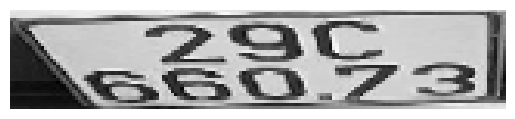

In [6]:
import matplotlib.pyplot as plt

def predict_plate(image_path):

    img = load_image(image_path)

    plt.imshow(np.squeeze(img), cmap='gray')
    plt.axis('off')
    
    img = np.expand_dims(img, axis=0)
    pred = model.predict(img)

    plate = decode_prediction(pred)

    return plate

predict_plate("/kaggle/input/datasets/hoangvudinh0301/rcnn-dataset/full_plate_dataset/29C660=73_3021.png")